In [3]:
# -*- coding: utf-8 -*-
import numpy as np

from pathlib import Path

from carm import (
    BoreholeGeometry,
    BoreholeMesh,
    BoreholeThermalProperties,
    SingleUtube,
)
from carm import GroundGeometry, GroundMesh
from carm import PhysicalModel
from carm import Simulation
from carm import Fluid
from carm import EnvironmentalProperties, EnvironmentalTimeSeries
from carm import FieldInput


# field
field_path = Path("spacing.xlsx")
path = Path("input_env.xlsx")

n_bhes = 9
x_min = -2.5
y_min = -2.5
x_max = 12.5
y_max = 12.5

# ground properties
stratification = [(1.8, 947.37, 1900, 111)]
n_mesh = 20
m_mesh = 40
D0 = 0.15
rn = 10
Tg = 13
f = 1.2
L = 100  # 12 #m lunghezza peforazione
m_mesh_sup = 4
m_mesh_inf = 40
L_sup = 1
L_inf = 10

segments = 8

# fluid properties
k_w = 0.568709114496803
rho_w = 1000.1435933169
cp_w = 4207.40834247225
ni_w = 1.49626063208248e-6

# borehole properties
# single e double u tube
Dpi = 0.026
Lbore = 100
Rp0 = 0.25
RppB = 0.72
n_pipes = 2
pipe_thick = 0.003
pipe_spacing = 0.0823
cp_0 = 1460
rho_0 = 1655
D0 = 0.15
conf = 1
k0 = 1.8

# external environment properties
absorptance = 0.7
eps = 0.95
At = 10
tau = 0
tau_y = 365 * 24 * 3600
tau_shift = 210 * 24 * 3600
R_ext = 0.04

# external environment input data
T_ext = np.full(276, 5)
SolarRad = np.full(276, 150)
Tm = 13

# simulation
dt = 3600
n_steps = 2160#276

# mw_tot and Tf1
Tf1 = np.full(n_steps, 2, dtype=np.float64)
mw_tot = np.full(n_steps, 0.1657, dtype=np.float64)

Tf1_multi = np.empty((n_bhes, n_steps))
mw_tot_multi = np.empty((n_bhes, n_steps))

Tf1_multi[:] = Tf1
mw_tot_multi[:] = mw_tot

# -----field-----
myfield = FieldInput(n_bhes=n_bhes, xmin=x_min, ymin=y_min, xmax=x_max, ymax=y_max, rb=D0 / 2.0)
myfield.from_excel(field_path)

# -----fluid-----
fluid = Fluid(k_w=k_w, rho_w=rho_w, cp_w=cp_w, ni_w=ni_w)

# -----borehole-----
bore_geom = BoreholeGeometry(Lbore=Lbore, D0=D0)
bore_mesh = BoreholeMesh(m_mesh=m_mesh)
bore_th_props = BoreholeThermalProperties(cp_0=cp_0, rho_0=rho_0, k0=k0)
props_b = SingleUtube(
    geom=bore_geom,
    mesh=bore_mesh,
    thermalprops=bore_th_props,
    fluid=fluid,
    Rp0=Rp0,
    RppB=RppB,
    pipe_spacing=pipe_spacing,
    pipe_thick=pipe_thick,
    Dpi=Dpi,
    n_pipes=n_pipes,
)

# -----ground-----
ground_geom = GroundGeometry(D0=D0, L=L, L_sup=L_sup, L_inf=L_inf, rn=None)
ground_mesh = GroundMesh(
    n_mesh=n_mesh,
    m_mesh=m_mesh,
    m_mesh_sup=m_mesh_sup,
    m_mesh_inf=m_mesh_inf,
    segments=segments,
)

# -----external environment-----
env_input = EnvironmentalTimeSeries.from_excel(Tm=Tm, path=path)
env_props = EnvironmentalProperties(
    R_ext=R_ext,
    absorptance=absorptance,
    eps=eps,
    At=At,
    tau=tau,
    tau_y=tau_y,
    tau_shift=tau_shift,
)

# -----model-----
model = PhysicalModel(
    ground_geom=ground_geom,
    ground_mesh=ground_mesh,
    borehole=props_b,
    fluid=fluid,
    Tg=Tg,
    stratification=stratification,
    fieldinput=myfield,
)

# -----simulation-----
simulation = Simulation(
    model=model, envinput=env_input, timesteps=dt, n_steps=n_steps, envprops=env_props, mw_tot=mw_tot_multi, Tf1=Tf1_multi
)
T_history = simulation.run(parallel=True)


T_ext and SolarRad lengths > n_steps, the first n_steps values are used
running time: 28.652727603912354 seconds


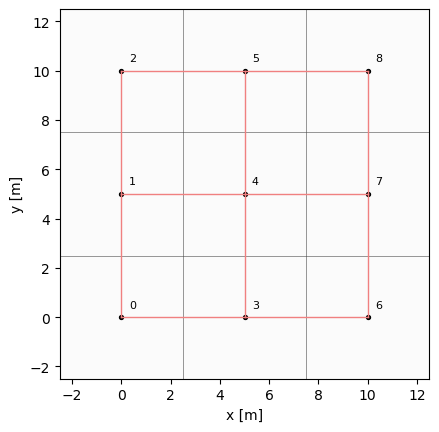

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [m]', ylabel='y [m]'>)

In [4]:
model.field.plot_field(show_ids=True, show_graph=True)

In [5]:
nsup = m_mesh_sup + 1
nground = n_mesh * m_mesh
nb = n_mesh * props_b.n_equations
ninf = m_mesh_inf
reference_borehole = 0

time = np.arange(dt, dt * (n_steps + 1), dt, dtype=np.float64,)

In [6]:
import matplotlib.pyplot as plt

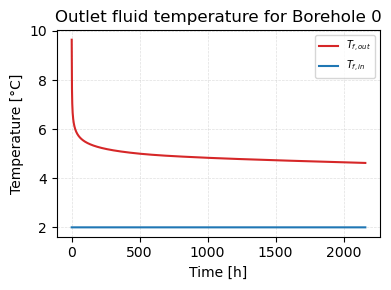

In [7]:
Tfout = T_history[1:, reference_borehole, nsup + nground + (props_b.n_equations - 1)]
fig, ax = plt.subplots(figsize = (4, 3)) #to create figure + one Axes

ax.plot(time / 3600, Tfout, color = "tab:red", label = r"$T_{f,out}$")
ax.plot(time / 3600, Tf1, color = "tab:blue", label = r"$T_{f,in}$")
ax.set_xlabel("Time [h]")
ax.set_ylabel("Temperature [°C]")
ax.set_title(f"Outlet fluid temperature for Borehole {reference_borehole}")
ax.legend(fontsize = 7)

ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.5, alpha = 0.4)

plt.tight_layout()
plt.show()

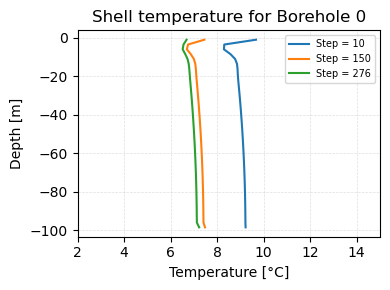

In [8]:
slice_depth_shell = [nsup + nground + j*props_b.n_equations for j in range(m_mesh)]

depth = np.arange(- L_sup, - L_sup - model.ground[0].dz * (m_mesh), - model.ground[0].dz)

Tshell_10 = T_history[10, reference_borehole, slice_depth_shell]
Tshell_150 = T_history[150, reference_borehole, slice_depth_shell]
Tshell_276 = T_history[276, reference_borehole, slice_depth_shell]

fig, ax = plt.subplots(figsize = (4, 3))

ax.plot(Tshell_10, depth, label = 'Step = 10')
ax.plot(Tshell_150, depth, label = 'Step = 150')
ax.plot(Tshell_276, depth, label = 'Step = 276')
ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("Depth [m]")
ax.set_xlim(2, 15)
ax.legend(fontsize = 7)
ax.set_title(f"Shell temperature for Borehole {reference_borehole}")

ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.5, alpha = 0.4)

plt.tight_layout()
plt.show()

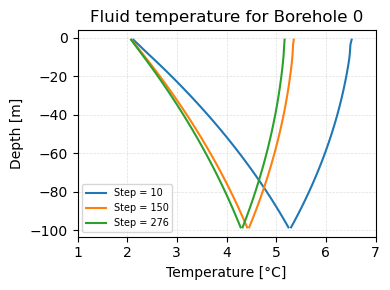

In [9]:
slice_down = [nsup + nground +  (props_b.n_equations * j) + (props_b.n_equations - 2) for j in range(m_mesh)]
slice_up = [nsup + nground + (props_b.n_equations * j) + (props_b.n_equations - 1) for j in range(m_mesh)]

depth = np.arange(- L_sup, - L_sup - model.ground[0].dz * (m_mesh), - model.ground[0].dz)

T_down_10= T_history[10, reference_borehole, slice_down]
T_down_150= T_history[150, reference_borehole, slice_down]
T_down_276= T_history[276, reference_borehole, slice_down]

T_up_10= T_history[10, reference_borehole, slice_up]
T_up_150= T_history[150, reference_borehole, slice_up]
T_up_276= T_history[276, reference_borehole, slice_up]

fig, ax = plt.subplots(figsize = (4, 3))

ax.plot(T_down_10, depth, color = "tab:blue", linestyle = "-", label = "Step = 10")
ax.plot(T_up_10, depth, color = "tab:blue", linestyle = "-")
ax.plot(T_down_150, depth, color = "tab:orange", linestyle = "-", label = "Step = 150")
ax.plot(T_up_150, depth, color = "tab:orange", linestyle = "-")
ax.plot(T_down_276, depth, color = "tab:green", linestyle = "-", label = "Step = 276")
ax.plot(T_up_276, depth, color = "tab:green", linestyle = "-")
ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("Depth [m]")
ax.set_xlim(1, 7)
ax.legend(fontsize = 7)
ax.set_title(f"Fluid temperature for Borehole {reference_borehole}")

ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.5, alpha = 0.4)

plt.tight_layout()
plt.show()

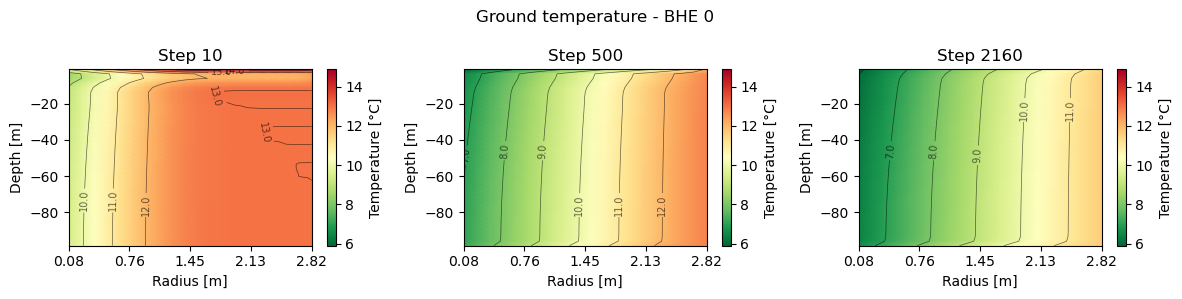

In [10]:
nsup = m_mesh_sup + 1
steps = [10, 500, 2160]
r0 = model.ground[0].r0
rn = model.ground[0].rn
dz = model.ground[0].dz

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
ax1, ax2, ax3 = axes

T_all = np.array([T_history[steps, reference_borehole, nsup : nsup + nground ]]).reshape(len(steps), m_mesh, n_mesh)

vmin, vmax = T_all.min(), T_all.max()

x_ticks = np.round(np.linspace(r0, rn, 5), decimals = 2)

depth = np.arange(-L_sup, -L_sup - dz * m_mesh, -dz)
radius = np.linspace(D0/2, rn, n_mesh)
R, D = np.meshgrid(radius, depth)

for i, (t, ax) in enumerate(zip(steps, axes)):

    pc = ax.pcolormesh(R, D, T_all[i], cmap='RdYlGn_r', shading='gouraud', vmin=vmin, vmax=vmax)
    contours = ax.contour(R, D, T_all[i], levels=6, colors='black', linewidths=0.5, alpha=0.6)
    ax.clabel(contours, inline=True, fontsize=7, fmt='%.1f', inline_spacing=5)
    ax.set_xlabel("Radius [m]")
    ax.set_ylabel("Depth [m]")
    fig.colorbar(pc, ax=ax, label="Temperature [°C]")
    ax.set_title(f"Step {t}")
    ax.set_xlim((r0, rn))
    ax.set_xticks(x_ticks)

fig.suptitle(f"Ground temperature - BHE {reference_borehole}")
plt.tight_layout()
plt.show()

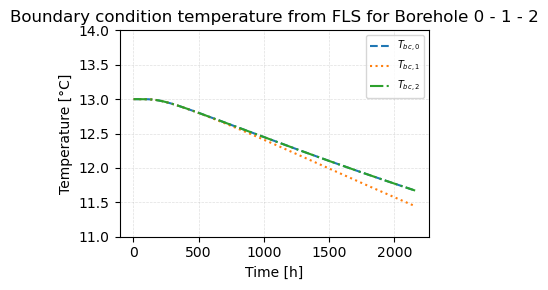

In [11]:
bhes = [0, 1, 2]
T_bc_mean = np.mean(simulation.T_bc[:, bhes, :], axis = 2)

Tbc0 = T_bc_mean[:, 0]
Tbc1 = T_bc_mean[:, 1]
Tbc2 = T_bc_mean[:, 2]

fig, ax = plt.subplots(figsize = (4, 3))

ax.plot(time / 3600, Tbc0, linestyle = "--", label = r"$T_{bc,0}$")
ax.plot(time / 3600, Tbc1, linestyle = ":", label = r"$T_{bc,1}$")
ax.plot(time / 3600, Tbc2, linestyle = "-.", label = r"$T_{bc,2}$")

ax.legend(fontsize = 7)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Temperature [°C]")
ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.5, alpha = 0.4)
ax.set_ylim(11, 14)

ax.set_title("Boundary condition temperature from FLS for Borehole 0 - 1 - 2")
plt.tight_layout()
plt.show()
